In [ ]:
import pandas as pd      ###importing required libraries###
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [5]:
from google.colab import files
uploaded = files.upload()

Saving fear_greed_index.csv to fear_greed_index.csv
Saving historical_data.csv to historical_data (1).csv


In [6]:
import pandas as pd

# Check uploaded file names
import os
print(os.listdir())

['.config', '.ipynb_checkpoints', 'historical_data.csv', 'fear_greed_index.csv']


In [8]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

print(trades.head())
print(sentiment.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [9]:
print(trades.info())
print(sentiment.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [11]:
import pandas as pd

# Convert to datetime
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

# Create date column (already exist, but ensure correct types)
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

# Drop missing values (after conversion, for rows where conversion failed)
trades = trades.dropna(subset=['Timestamp IST'])
sentiment = sentiment.dropna(subset=['date'])

In [12]:
merged = pd.merge(trades, sentiment, on='date', how='inner')

print(merged.head())
print(merged.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-02-12 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-02-12 22:50:00      986.524596       Buy   
2       144.09   1150.63  BUY 2024-02-12 22:50:00     1002.518996       Buy   
3       142.98   1142.04  BUY 2024-02-12 22:50:00     1146.558564       Buy   
4         8.73     69.75  BUY 2024-02-12 22:50:00     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0

In [14]:
# Profit
merged['profit'] = merged['Closed PnL']

# Profit flag
merged['is_profit'] = merged['profit'] > 0

# Trade size category
merged['size_category'] = pd.cut(
    merged['Size USD'],
    bins=3,
    labels=['Small', 'Medium', 'Large']
)

# Display the results
display(merged[['Closed PnL', 'profit', 'is_profit', 'size_category']].head())

,Closed PnL,profit,is_profit,size_category
0,0.0,0.0,False,Small
1,0.0,0.0,False,Small
2,0.0,0.0,False,Small
3,0.0,0.0,False,Small
4,0.0,0.0,False,Small


In [16]:
profit_by_sentiment = merged.groupby('classification')['profit'].mean()
print(profit_by_sentiment)

classification
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: profit, dtype: float64


In [18]:
win_rate = merged.groupby('classification')['is_profit'].mean()
print(win_rate)

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: is_profit, dtype: float64


In [19]:
win_rate = merged.groupby('classification')['is_profit'].mean()
print(win_rate)

classification
Extreme Fear     0.292777
Extreme Greed    0.553282
Fear             0.381787
Greed            0.435707
Neutral          0.494920
Name: is_profit, dtype: float64


In [21]:
# Check available columns to see what can be analyzed
print("Available columns:")
print(merged.columns.tolist())

# Example: Grouping by a column that DOES exist, like 'Size USD'
# average_size = merged.groupby('classification')['Size USD'].mean()
# print('\nAverage Size USD by Sentiment:')
# print(average_size)

Available columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'timestamp', 'value', 'classification', 'profit', 'is_profit', 'size_category']


In [23]:
volume = merged.groupby('classification')['Size USD'].sum()
print(volume)

classification
Extreme Fear      9580240.04
Extreme Greed    18223760.27
Fear             79674391.06
Greed            57045815.74
Neutral          11939551.21
Name: Size USD, dtype: float64


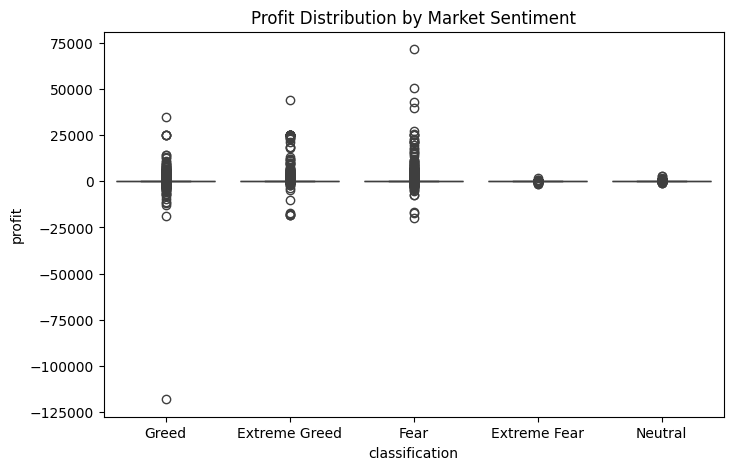

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='profit', data=merged)
plt.title("Profit Distribution by Market Sentiment")
plt.show()

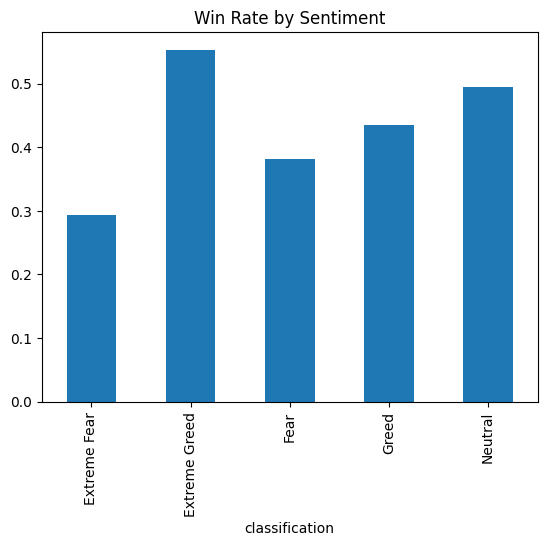

In [26]:
win_rate.plot(kind='bar', title="Win Rate by Sentiment")
plt.show()

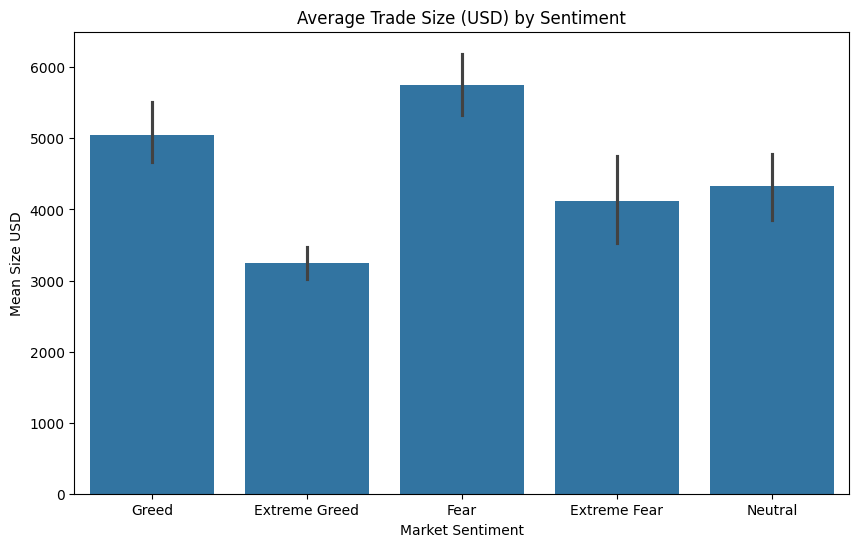

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Size USD', data=merged, estimator='mean')
plt.title("Average Trade Size (USD) by Sentiment")
plt.ylabel("Mean Size USD")
plt.xlabel("Market Sentiment")
plt.show()

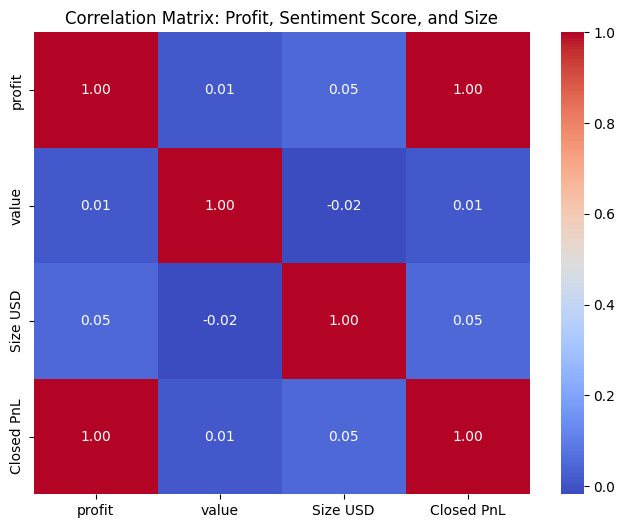

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Selecting numerical columns that exist in the dataframe
# 'value' is the Fear & Greed numerical score
corr_columns = ['profit', 'value', 'Size USD', 'Closed PnL']
corr = merged[corr_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix: Profit, Sentiment Score, and Size")
plt.show()

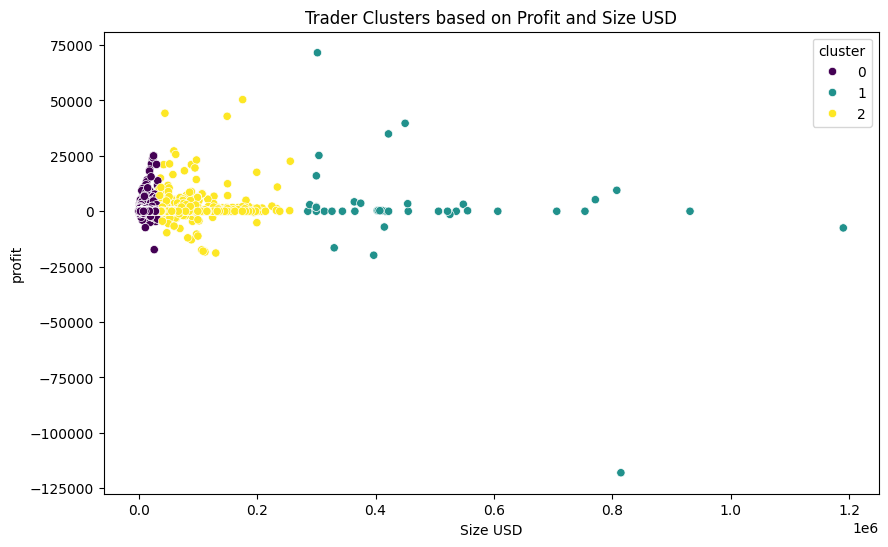

In [32]:
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

# Using existing columns for clustering
X = merged[['profit', 'Size USD']].fillna(0)

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
merged['cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Size USD', y='profit', hue='cluster', palette='viridis', data=merged)
plt.title("Trader Clusters based on Profit and Size USD")
plt.show()

In [33]:
print(merged['classification'].value_counts())

classification
Fear             13869
Greed            11292
Extreme Greed     5621
Neutral           2756
Extreme Fear      2326
Name: count, dtype: int64
